In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create local output folder for visualizations
os.makedirs('results/eda_visualizations', exist_ok=True)

# Load dataset
df = pd.read_csv('BankChurners.csv')
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (10127, 23)


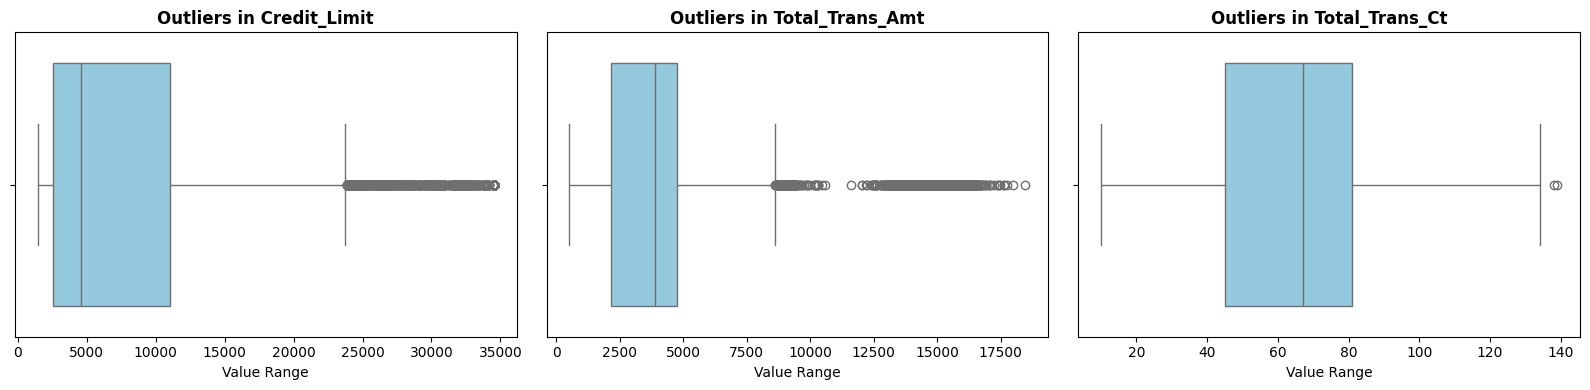

Plot saved successfully to: results/eda_visualizations/IT25102091_outlier_boxplots.png
Rows with at least one outlier value: 1684 out of 10127


In [4]:
# 1. Select genuine continuous banking attributes
outlier_features = ['Credit_Limit', 'Total_Trans_Amt', 'Total_Trans_Ct']

# 2. Generate Boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(outlier_features):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value Range')

plt.tight_layout()

# 3. Save the required deliverable visual
plot_file = 'results/eda_visualizations/IT25102091_outlier_boxplots.png'
plt.savefig(plot_file, dpi=300)
plt.show()
print(f"Plot saved successfully to: {plot_file}")

# 4. IQR Calculation on core numeric features
Q1 = df[outlier_features].quantile(0.25)
Q3 = df[outlier_features].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[outlier_features] < (Q1 - 1.5 * IQR)) | (df[outlier_features] > (Q3 + 1.5 * IQR)))
print("Rows with at least one outlier value:", outlier_mask.any(axis=1).sum(), "out of", len(df))